### 학습목표 
- 유방암 환자 데이터를 활용하여 유방암 여부를 분류 (네, 아니오)
- 딥러닝을 활용하여 이진분류 딥러닝 모델 설계 및 학습 및 평가
- sklearn.datasets에서 제공하는 breast_cancer 활용

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 작업 디렉토리 설정 (본인 경로로 변경)
%cd /content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Deep Learning
!pwd

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Deep Learning
/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Deep Learning


In [3]:
## library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [4]:
data = load_breast_cancer()

In [5]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

- data : 입력특성, 문제데이터
- target : 정답데이터, Label(0,1) - 인덱스 형태
- target_names : 정답데이터의 실제 이름
- DESCR : 데이터에 대한 설명
- feature_names : 입력특성의 이름(컬럼명)

In [6]:
X = data['data']

In [7]:
y = data['target']

In [8]:
X.shape,y.shape

((569, 30), (569,))

In [9]:
# 정답데이터의 실제이름
data['target_names']
# 0 : malignant > 악성 (암)
# 1 : benign > 양성 (암이 아님)

array(['malignant', 'benign'], dtype='<U9')

In [10]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [11]:
print(data['DESCR'])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [12]:
# 학습용, 평가용 데이터로 분리
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42,stratify=y) 
# 훈련데이터셋과 테스트데이터셋에 비율을 맞춰서 만들어 주는 키워드 추가 필요

In [13]:
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(455, 30) (455,)
(114, 30) (114,)


In [14]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Dense

In [28]:
# 모델 뼈대 설계
model = Sequential()
# 모델 입력층
model.add(Input(shape=(30,)))
# 모델 중간층
model.add(Dense(units=8,activation='sigmoid'))
model.add(Dense(units=16,activation='sigmoid'))
model.add(Dense(units=32,activation='sigmoid'))
# 모델 출력층
model.add(Dense(units=1,activation = 'sigmoid'))
# 분류학습 결과는 확률값으로 출력 (이진분류 : 1개의 확률값 출력)
# 1번 class 일 확률 출력 1개 (확률값 0.5 이상이면 1번클래스로 분류,0.5미만이면 0번클래스로 분류)
# 선형 모델이 출력한 연속적인 값을 확률값으로 변경 -> 활성화 함수 사용.

##### 활성화함수(activation)
- 선형모델 + 추가연산
- 중간층에서의 역할과 출력층에서의 역할이 다르다
    - 중간층 : 역치 개념
        - sigmoid : step function에서 미분을 변형해주기 위해 변형
    - 출력층 : 선형모델이 예측한 결과에 추가 연산
        - sigmoid : 연속적인 값을 확률값으로 변경(0 ~ 1)

In [29]:
model.compile(
    loss = 'binary_crossentropy',
    optimizer = 'SGD',
    metrics = ['accuracy']
)

In [30]:
model.fit(X_train,y_train,epochs=50,validation_split=0.2)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3626 - loss: 0.8798 - val_accuracy: 0.4176 - val_loss: 0.7858
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3626 - loss: 0.7839 - val_accuracy: 0.4176 - val_loss: 0.7282
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3626 - loss: 0.7252 - val_accuracy: 0.4176 - val_loss: 0.6987
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5220 - loss: 0.6922 - val_accuracy: 0.5824 - val_loss: 0.6866
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6374 - loss: 0.6760 - val_accuracy: 0.5824 - val_loss: 0.6815
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6374 - loss: 0.6672 - val_accuracy: 0.5824 - val_loss: 0.6797
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6374 - loss: 0.6620 - val_accuracy: 0.5824 - val_loss: 0.6797
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6374 - loss: 0.6586 - val_accuracy: 0.5824 - val_loss

In [32]:
model.history.history

{'accuracy': [0.36263737082481384,
  0.36263737082481384,
  0.36263737082481384,
  0.5219780206680298,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775085,
  0.6373626589775

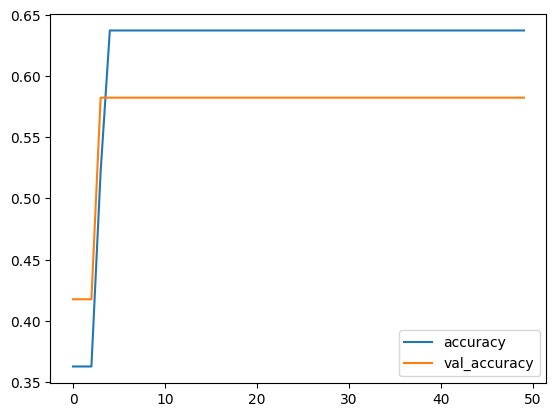

In [33]:
# 시각화
plt.plot(model.history.history['accuracy'],label = 'accuracy')
plt.plot(model.history.history['val_accuracy'],label = 'val_accuracy')
plt.legend()
plt.show()

In [31]:
model.evaluate(X_test,y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6316 - loss: 0.6583


[0.6583197712898254, 0.6315789222717285]

### [신경망 모델 모델링]
1. 신경망 모델 구조 설계
- 뼈대 생성 (Sequential)
- 입력층 (input(shape = ())), 입력받는 데이터의 형태를 지정
- 중간층, 은닉층 (Dense(units = ?,activation = ? ))
    - 모델의 핛브 선은ㅇ을 결정 (units의 개수가 많거나 층이 깊어지면 똑독해짐 but 과적합 주의!)
- 출력층 (Dense(units = ?, activation = ?))
    - 출력값의 형태를 정의
2. 학습방법 및 평가방법 설정 (compile)
    - loss : 비용함수, 학습에 사용하는 오차의 종류
        - 회귀 : mse
        - 분류 : crossentropy
    - optimizer : 최적화함수, 오차를 줄여나가는 방법에 대해서 설정. (GD, SGD, ) 
    - metrics : 평가지표
        - 회귀 : mse
        - 분류 : accuracy (정확도)
3. 모델학습(fit) 및 시각화
    - 데이터 : X_train,y_train
    - epochs : 학습 횟수
    - validation_split : 검증데이터의 비율
4. 모델평가
    - evaluate(X_test,y_test)